<a href="https://colab.research.google.com/github/AryaJagtap/AIQ-Tasks/blob/main/gisdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rasterio torch torchvision matplotlib tqdm

from google.colab import drive
drive.mount('/content/drive')


import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Progress bar

import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Update these two lines to match your exact folder paths
IMAGE_DIR = r"/content/drive/MyDrive/satellitle dataset/extracting_slums_from_satellite_imagery/extracting_slums_from_satellite_imagery/images"
LABEL_DIR = r"/content/drive/MyDrive/satellitle dataset/extracting_slums_from_satellite_imagery/extracting_slums_from_satellite_imagery/labels"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class SlumDataset(Dataset):
    def __init__(self, image_dir, label_dir, empty_ratio=0.2):
        self.image_dir = image_dir
        self.label_dir = label_dir

        # 1. Find all label files
        label_files = glob.glob(os.path.join(label_dir, "*.tif"))
        print(f"Checking {len(label_files)} candidate files...")

        self.valid_files = []
        self.empty_files = []

        # 2. Safety Check Loop
        for lbl_path in tqdm(label_files, desc="Verifying Pairs"):
            basename = os.path.basename(lbl_path)
            img_path = os.path.join(self.image_dir, basename)

            # CHECK: Does the matching image exist?
            if not os.path.exists(img_path):
                # If missing, skip silently
                continue

            # CHECK: Open label to see if it has data (slums) or is empty
            try:
                with rasterio.open(lbl_path) as src:
                    # Read a tiny preview (fast) to check for data
                    # We use a 1/10th scale overview for speed
                    data = src.read(1, out_shape=(1, int(src.height/10), int(src.width/10)))

                    if data.max() > 0:
                        self.valid_files.append(basename)
                    else:
                        self.empty_files.append(basename)
            except Exception as e:
                print(f"Error reading {basename}: {e}")

        # 3. Balancing (Mix some empty files in so the AI learns background too)
        num_empty = int(len(self.valid_files) * empty_ratio)
        selected_empty = random.sample(self.empty_files, min(num_empty, len(self.empty_files)))

        self.final_list = self.valid_files + selected_empty
        print(f"\nSUCCESS: Found {len(self.valid_files)} Slum images + {len(selected_empty)} Background images.")
        print(f"Total Dataset Size: {len(self.final_list)}")

    def __len__(self):
        return len(self.final_list)

    def __getitem__(self, idx):
        filename = self.final_list[idx]
        img_path = os.path.join(self.image_dir, filename)
        lbl_path = os.path.join(self.label_dir, filename)

        # Load Image (Input)
        with rasterio.open(img_path) as src:
            # Read and Normalize (0-255 -> 0.0-1.0)
            image = src.read().astype(np.float32) / 255.0

        # Load Label (Target)
        with rasterio.open(lbl_path) as src:
            label = src.read(1).astype(np.int64)

        return torch.from_numpy(image), torch.from_numpy(label)

# --- CREATE THE DATA LOADER ---
# This actually runs the code above
dataset = SlumDataset(IMAGE_DIR, LABEL_DIR)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)

Checking 2331 candidate files...


Verifying Pairs:   0%|          | 0/2331 [00:00<?, ?it/s]


SUCCESS: Found 1497 Slum images + 299 Background images.
Total Dataset Size: 1796


In [ ]:
# 1. Install the Pro Segmentation Library
!pip install segmentation-models-pytorch rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

# 1. Setup Device (GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# 2. Create the Model using the Library
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=2
)

model.to(device)
print("Model loaded successfully!")

Training on: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
# Settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
NUM_EPOCHS = 3

print("Starting Training...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        # 1. Forward Pass
        # The library model returns the prediction directly
        outputs = model(images)

        # 2. Calculate Loss
        loss = criterion(outputs, masks)

        # 3. Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Avg Loss: {running_loss / len(train_loader):.4f}")

# Save the smart model
torch.save(model.state_dict(), "resnet_slum_model.pth")
print("Training Complete & Model Saved!")

Starting Training...


Epoch 1/3:   0%|          | 0/225 [00:00<?, ?it/s]

Epoch 1 Avg Loss: 0.3012


Epoch 2/3:   0%|          | 0/225 [00:00<?, ?it/s]

Epoch 2 Avg Loss: 0.1632


Epoch 3/3:   0%|          | 0/225 [00:00<?, ?it/s]

Epoch 3 Avg Loss: 0.1068
Training Complete & Model Saved!


Checking results...


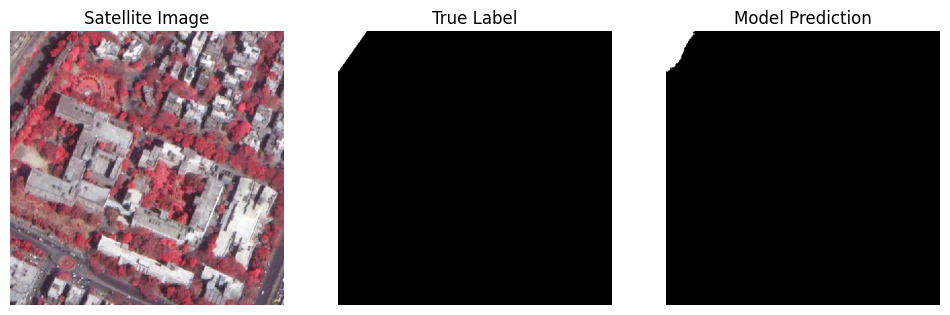

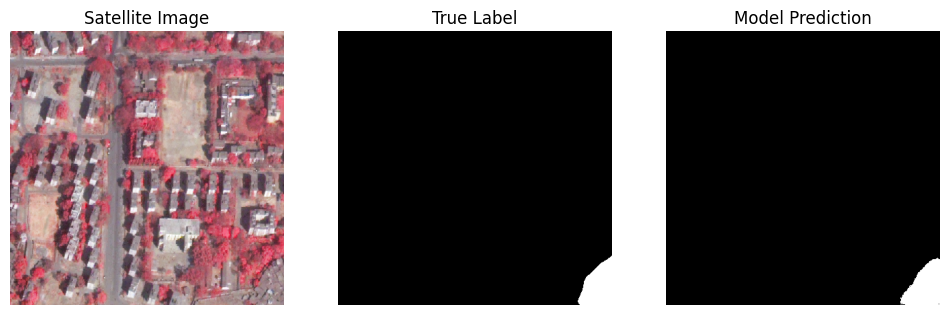

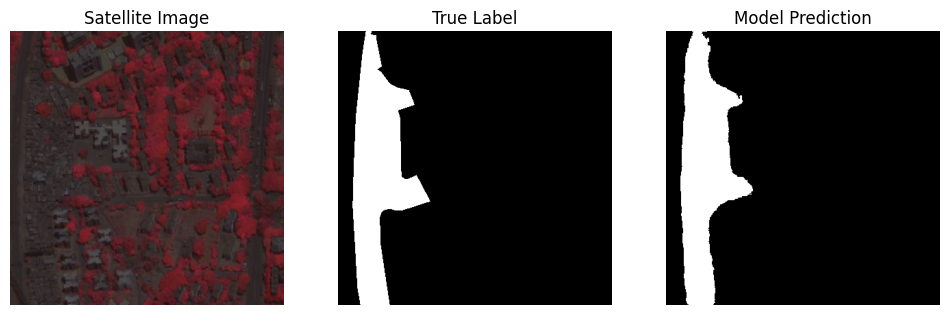

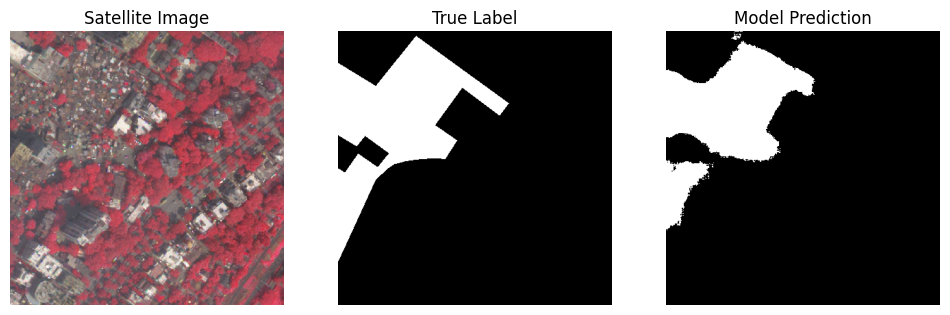

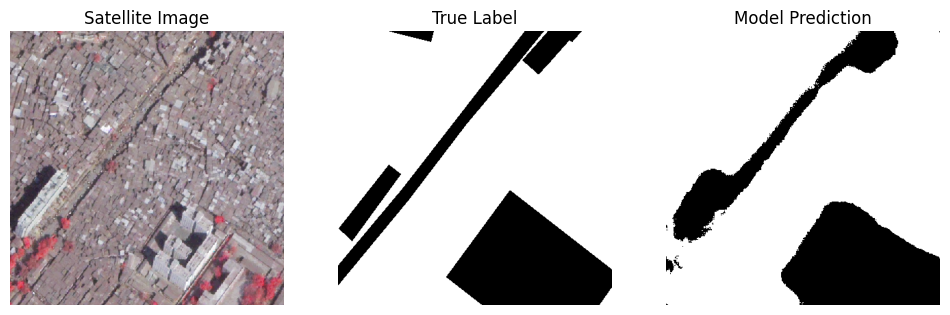

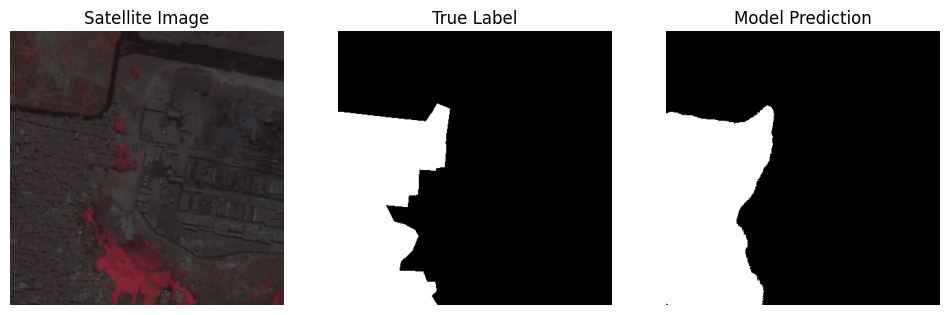

In [ ]:
model.eval()
images, masks = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    output = model(images)
    preds = torch.argmax(output, dim=1)

def show_result(idx):
    plt.figure(figsize=(12, 4))

    # Original
    plt.subplot(1, 3, 1)
    img_np = images[idx].cpu().permute(1, 2, 0).numpy()
    plt.imshow(img_np)
    plt.title("Satellite Image")
    plt.axis('off')

    # True Label
    plt.subplot(1, 3, 2)
    plt.imshow(masks[idx].cpu().numpy(), cmap='gray')
    plt.title("True Label")
    plt.axis('off')

    # Prediction
    plt.subplot(1, 3, 3)
    plt.imshow(preds[idx].cpu().numpy(), cmap='gray')
    plt.title("Model Prediction")
    plt.axis('off')

    plt.show()

print("Checking results...")
show_result(0)
show_result(1)
show_result(2)

show_result(3)
show_result(4)
show_result(5)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm

# --- 1. SETUP MODEL & OPTIMIZER ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the pre-trained U-Net
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=2
).to(device)

# Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# --- 2. TRAINING LOOP ---
NUM_EPOCHS = 2 # Recommended: 10 to 20 epochs
best_val_loss = float('inf') # Track the best score

print(f"Starting Training on {device}...")

for epoch in range(NUM_EPOCHS):


    model.train() # Turn on dropout/batchnorm
    train_loss = 0.0

    # Progress bar for training
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)


        outputs = model(images)
        loss = criterion(outputs, masks)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0


    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)


    print(f"--> Epoch {epoch+1} Summary:")
    print(f"    Train Loss: {avg_train_loss:.4f}")
    print(f"    Valid Loss: {avg_val_loss:.4f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_slum_model.pth")
        print("    [+] Validation improved. Model saved!")
    else:
        print("    [-] Validation did not improve.")

print("\nTraining Complete!")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Starting Training on cpu...


Epoch 1/2 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]